# Netflix Content Strategy — Exploratory Data Analysis

Netflix is one of the world's most influential streaming platforms, with a catalog
spanning thousands of titles across more than 190 countries. Every decision about
what content to add — what type, from which country, in which genre, at what point
in its lifecycle — reflects a deliberate business strategy.

This project uses Exploratory Data Analysis (EDA) to read those signals directly
from the data. Rather than simply describing what the dataset contains, each
question in this analysis asks *why* the data looks the way it does, and what it
tells us about how Netflix operates as a business.

**Dataset:** Netflix Movies and TV Shows (Kaggle, ~8,800 titles)  
**Tools:** Python, Pandas, Matplotlib, Seaborn

## Project Objectives

1. Assess the quality of the dataset — missing values, data types, and anomalies
2. Understand how Netflix's content library is distributed across types and genres
3. Identify trends in content additions over time
4. Investigate the geographic diversity of Netflix's catalog
5. Explore whether Netflix's content strategy has shifted toward fresher, more
   international content over the years
6. Practice choosing the right chart for each type of question

## Import the libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

sns.set(style="whitegrid")

## Data Loading

**The dataset was downloaded from Kaggle and loaded locally to ensure reproducibility and avoid dependency on external APIs.**

In [2]:
df = pd.read_csv('netflix_titles.csv')

## Dataset Overview

The dataset contains metadata about Netflix titles including:

- **type** — Movie or TV Show  
- **title** — Name of the content  
- **director** — Director of the title  
- **cast** — Actors appearing in the title  
- **country** — Country of production  
- **date_added** — Date the title was added to Netflix  
- **release_year** — Year the title was originally released  
- **rating** — Age classification rating  
- **duration** — Movie length or number of seasons  
- **listed_in** — Genre categories

In [3]:
df.shape

(8807, 12)

**The dataset contains 8,807 rows and 12 columns, representing various attributes of Netflix titles such as type, director, cast, country, rating, and genre.**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


**You can see basic information about the Pandas DataFrame, such as data types, RangeIndex, column names, etc., and every column has a data type of `object` except `release_year`. This is because `object` is how Pandas represents text or mixed-type columns. It is not an error — it simply means the column holds strings.**

In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


**`.describe()` method is useful to see the statistical information of the data, like mean, standard deviation, etc. `release_year` is the only column that contains numerical values, so as you can see, the average release year of movies and TV shows is 2014.** 

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

**Let's see some data inside the dataset to get a better idea of what's going on, different features that we have and what needs to be worked upon.**

In [7]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df.tail(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


**Let's see some random rows and that can be done by `.sample()` method just by passing the number of examples you want to see.**

In [9]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
804,s805,Movie,Population 436,Michelle MacLaren,"Jeremy Sisto, Fred Durst, Charlotte Sullivan, ...","Canada, United States","June 2, 2021",2006,R,93 min,"Horror Movies, Thrillers",A census taker sent to investigate why Rockwel...
7126,s7127,Movie,Jersey Boys,Clint Eastwood,"John Lloyd Young, Erich Bergen, Michael Lomend...",United States,"January 1, 2019",2014,R,134 min,"Dramas, Music & Musicals","Adapted from the hit Broadway musical, this no..."
4856,s4857,TV Show,Dance & Sing with True,NaN,"Michela Luci, Jamie Watson, Anna Claire Bartla...",NaN,"May 18, 2018",2018,TV-Y,1 Season,Kids' TV,True and her friends are making music – and th...
2872,s2873,TV Show,Unstoppable,NaN,"Tessa Ia, Bárbara López, Lucía Uribe, Coty Cam...",Mexico,"February 28, 2020",2020,TV-MA,1 Season,"International TV Shows, Spanish-Language TV Sh...",A group of friends set out on a road trip when...
3017,s3018,Movie,Jezebel,Numa Perrier,"Tiffany Tenille, Numa Perrier, Stephen Barring...",United States,"January 16, 2020",2019,TV-MA,86 min,"Dramas, Independent Movies","During the internet's infancy, a vulnerable wo..."


**We can also filter the DataFrame to look at just one content type.**

In [10]:
df[df.type == 'Movie'].head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [11]:
df[df.type == "TV Show"].head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...


**You can access a subset of a dataframe by passing a list of columns.**

In [12]:
df[["type", "title", "country", "release_year", "rating"]]

,type,title,country,release_year,rating
0,Movie,Dick Johnson Is Dead,United States,2020,PG-13
1,TV Show,Blood & Water,South Africa,2021,TV-MA
2,TV Show,Ganglands,NaN,2021,TV-MA
3,TV Show,Jailbirds New Orleans,NaN,2021,TV-MA
4,TV Show,Kota Factory,India,2021,TV-MA
...,...,...,...,...,...
8802,Movie,Zodiac,United States,2007,R
8803,TV Show,Zombie Dumb,NaN,2018,TV-Y7
8804,Movie,Zombieland,United States,2009,R
8805,Movie,Zoom,United States,2006,PG


In [13]:
df.loc[100]

show_id                                                      s101
type                                                      TV Show
title                                     Tobot Galaxy Detectives
director                                                      NaN
cast            Austin Abell, Travis Turner, Cole Howard, Anna...
country                                                       NaN
date_added                                      September 7, 2021
release_year                                                 2019
rating                                                      TV-Y7
duration                                                2 Seasons
listed_in                                                Kids' TV
description     An intergalactic device transforms toy cars in...
Name: 100, dtype: object

## Data Cleaning and Feature Engineering

Let's start by checking missing values because, in general, the real-world datasets are too messy and unstructured, so we should clean the data before visualizing anything.

In [14]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

The dataset contains missing values, especially `director` contains **2634**, followed by `country` **831**, `cast` **825** and so on. It happens when the provider does not provide the actual information for some sort of reason and **Pandas** directly converts those missing or unknown values into **NaN** which stands for **Not a number**.

**Let's visualize the missing values with a bar plot.**

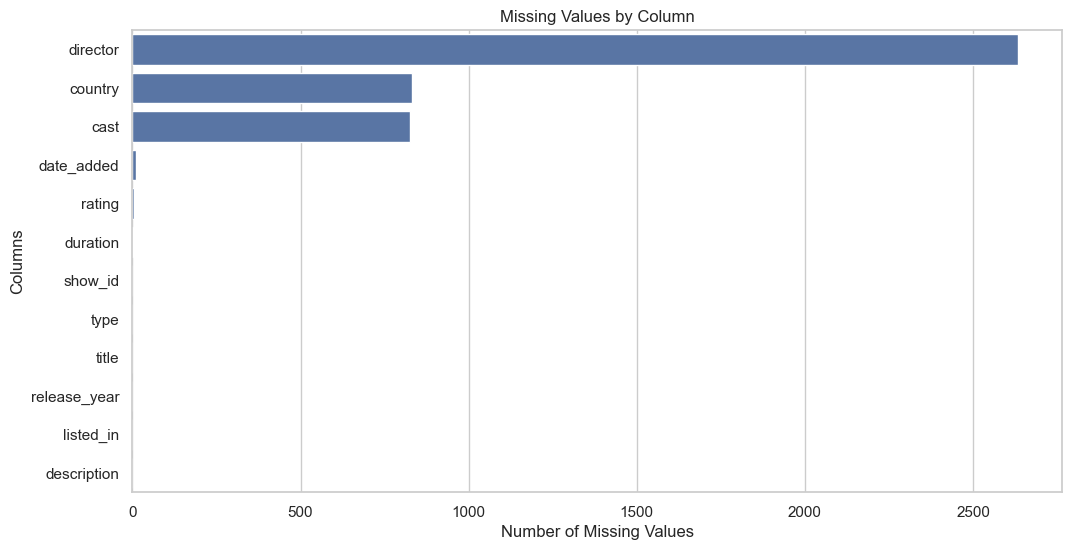

In [15]:
missing = df.isnull().sum().sort_values(ascending=False)

# Bar plot
plt.figure(figsize=(12,6))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")
plt.show()

In [16]:
# Check whether any duplicate rows exist
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Let's examine the `country` column specifically, since it has 831 missing
values and will be used in several later questions.**

In [17]:
df.country.value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [18]:
df.country.isnull().sum()

np.int64(831)

If you notice in the above cells, 831 entries have NaN values i.e., there are no values assigned to them. Now the problem is, filling missing values with `"Unknown"` will make it look like a real country. `"Unknown"` will appear as a 3rd most common country (831 times). That is not real data -  it's our own fill value that is polluting the chart. Better options are described below.

**Strategy chosen:** We leave `director`, `cast`, and `country` as `NaN`
rather than filling them with "Unknown". In every chart that uses these
columns, we will use `dropna=True` or filter out NaN values directly.
This keeps the data honest — a missing value stays missing rather than
becoming a fake category that pollutes the counts.

The `date_added` column is converted to a datetime format to enable time-based analysis, such as extracting the year and month when content was added to Netflix. Also, cast the data type to `int` because it will give float values after formatting. 

In [19]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

df["year_added"] = df["date_added"].dt.year.astype("Int64")
df["month_added"] = df["date_added"].dt.month.astype("Int64")

**Let's confirm the new columns were created correctly.**

In [20]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


**What will be the content age?**

`content_age` tells us how old a title was when Netflix added it. A value of 0
means it was added the same year it was released (likely a Netflix Original).
A value of 10 means it is catalog content licensed years after release.

In [21]:
df["content_age"] = df["year_added"] - df["release_year"]

Some `content_age` values are negative — these are data errors. We should flag and investigate:

In [22]:
df[df["content_age"] < 0][["title", "year_added", "release_year"]]

,title,year_added,release_year
1551,Hilda,2020,2021
1696,Polly Pocket,2020,2021
2920,Love Is Blind,2020,2021
3168,Fuller House,2019,2020
3287,Maradona in Mexico,2019,2020
3369,BoJack Horseman,2019,2020
3433,The Hook Up Plan,2019,2020
4844,Unbreakable Kimmy Schmidt,2018,2019
4845,Arrested Development,2018,2019
5394,Hans Teeuwen: Real Rancour,2017,2018


## Exploratory Data Analysis

### 🔎 Data Quality

#### Q1. What is the distribution of Movies and TV Shows?

In [23]:
df.type.value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

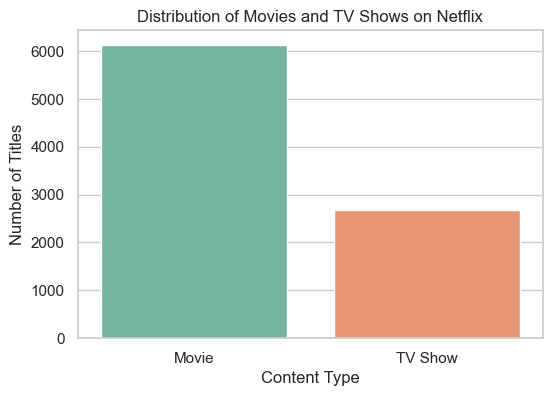

In [24]:
# Counter Plot
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df, hue="type", palette="Set2", legend=False)
plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

**Insight:** Movies make up roughly 70% of Netflix's catalog, significantly
outnumbering TV Shows. This reflects Netflix's early business model of licensing
large volumes of existing films to build a broad library quickly. TV Shows, while
fewer in number, often generate higher engagement since viewers return across
multiple episodes — a pattern Netflix has increasingly leaned into with its
original series strategy.

#### Q2. Why is the `director` field missing for ~30% of titles?

Director is missing for nearly 30% of titles. Before treating it as a
data problem, we should check — is it missing more for Movies or TV Shows?

Missing count by type:
type
Movie       188
TV Show    2446
Name: director, dtype: int64

Missing percentage by type:
type
Movie       3.1
TV Show    91.4
Name: director, dtype: float64


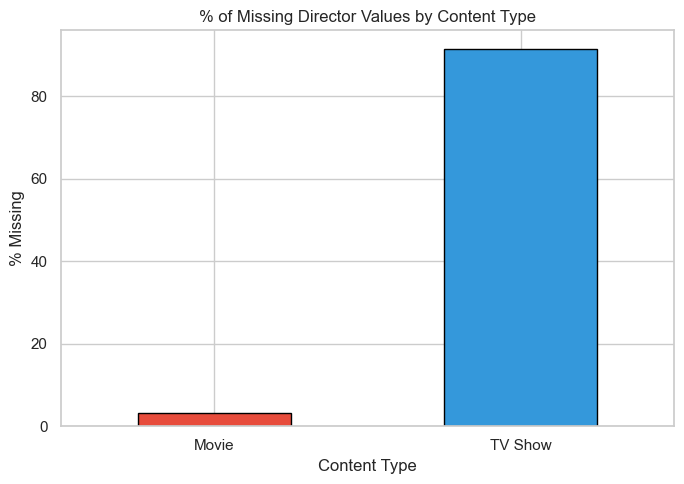

In [25]:
# Count how many directors are missing for each content type
missing_by_type = df.groupby("type")["director"].apply(lambda x: x.isna().sum())
print("Missing count by type:")
print(missing_by_type)

# Calculate the percentage missing for each type
missing_pct = df.groupby("type")["director"].apply(lambda x: round(x.isna().mean() * 100, 1))
print("\nMissing percentage by type:")
print(missing_pct)

# Simple bar chart
plt.figure(figsize=(7, 5))
missing_pct.plot(kind="bar", color=["#e74c3c", "#3498db"], edgecolor="black")
plt.title("% of Missing Director Values by Content Type")
plt.xlabel("Content Type")
plt.ylabel("% Missing")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** The missing director data is almost entirely from TV Shows, not
Movies. This makes sense — a movie typically has one director, but a TV show
runs across many episodes and seasons, each with a different director, so listing
a single name is not meaningful. This is not a data error; it is a structural
difference between the two content types.

#### Q3. How clean is the `duration` column?

The `duration` column stores two completely different units — minutes for
Movies and seasons for TV Shows. We need to separate them and check for
any strange values.

--- Movie Duration (minutes) ---
count    6128.0
mean       99.6
std        28.3
min         3.0
25%        87.0
50%        98.0
75%       114.0
max       312.0
Name: duration_min, dtype: float64

--- TV Show Seasons ---
count    2676.0
mean        1.8
std         1.6
min         1.0
25%         1.0
50%         1.0
75%         2.0
max        17.0
Name: seasons, dtype: float64


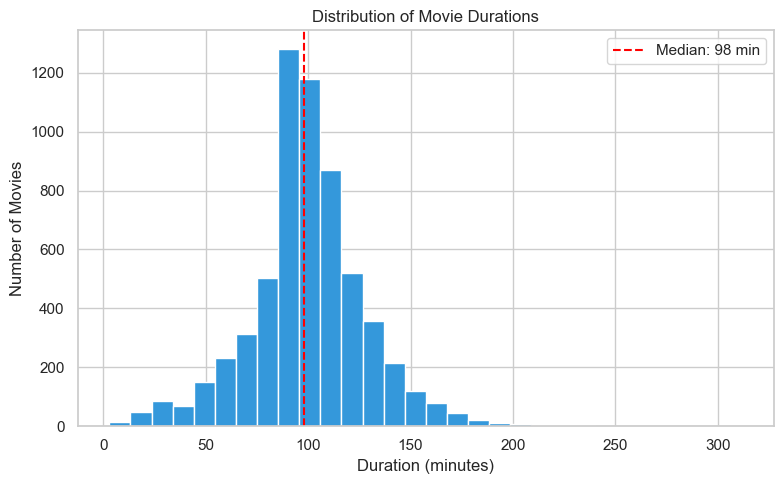

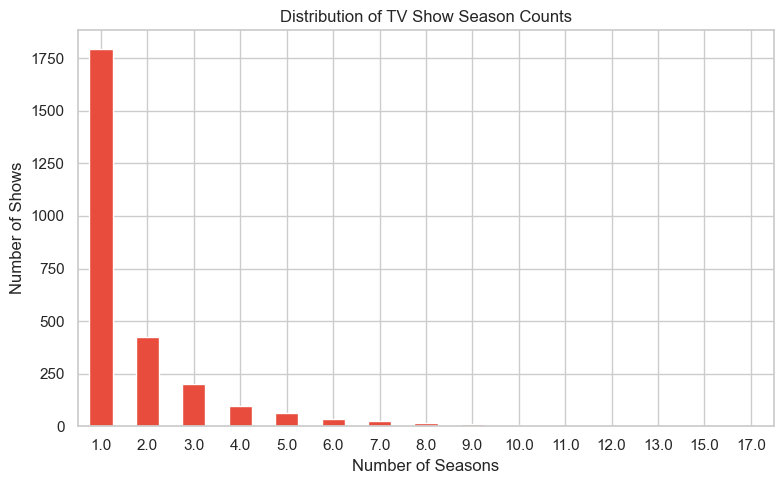

In [26]:
# Separate movies and TV shows into two DataFrames
movies_df = df[df["type"] == "Movie"].copy()
shows_df = df[df["type"] == "TV Show"].copy()

# Extract the number from the duration string for each type
# .str.extract(r"(\d+)") pulls out the first number it finds
movies_df["duration_min"] = movies_df["duration"].str.extract(r"(\d+)").astype(float)
shows_df["seasons"] = shows_df["duration"].str.extract(r"(\d+)").astype(float)

# Check the basic stats for each
print("--- Movie Duration (minutes) ---")
print(movies_df["duration_min"].describe().round(1))

print("\n--- TV Show Seasons ---")
print(shows_df["seasons"].describe().round(1))

# Plot movie duration distribution
plt.figure(figsize=(8, 5))
plt.hist(movies_df["duration_min"].dropna(), bins=30, color="#3498db", edgecolor="white")
plt.axvline(movies_df["duration_min"].median(), color="red", linestyle="--",
            label=f"Median: {movies_df['duration_min'].median():.0f} min")
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.legend()
plt.tight_layout()
plt.show()

# Plot TV show season distribution
plt.figure(figsize=(8, 5))
season_counts = shows_df["seasons"].value_counts().sort_index()
season_counts.plot(kind="bar", color="#e74c3c", edgecolor="white")
plt.title("Distribution of TV Show Season Counts")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of Shows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** Movie durations are mostly clean and cluster around 90–100 minutes,
which is the standard length for a theatrical film. TV Show season counts are
heavily skewed — the vast majority of Netflix shows have only 1–3 seasons,
which reflects Netflix's habit of cancelling most shows early. Only a small
number of older, legacy shows reach 6+ seasons.

### 📅 Time Trends

#### Q4. How has Netflix content grown over time?

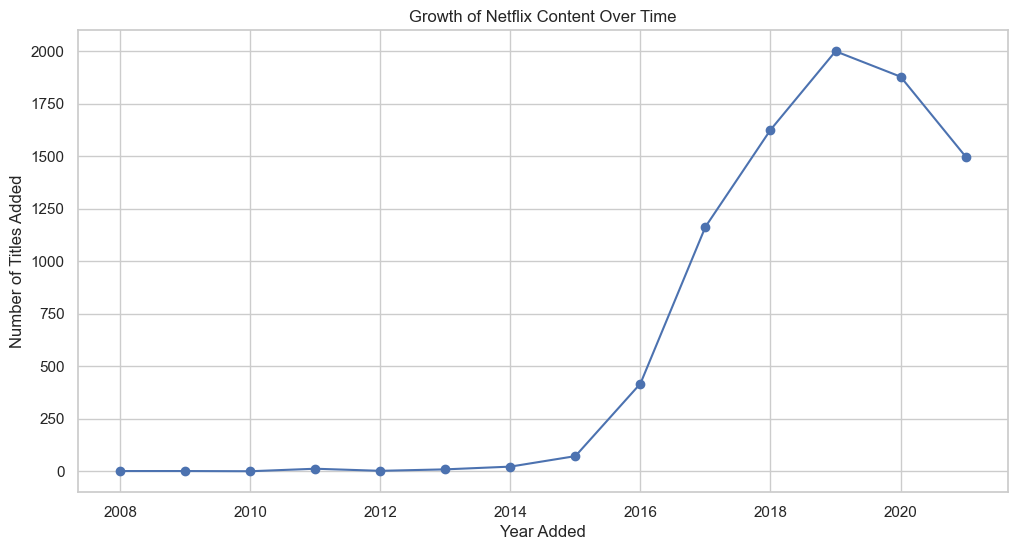

In [27]:
# Count the number of titles across all years
year_counts = df["year_added"].value_counts().sort_index()

# Line Chart
plt.figure(figsize=(12,6))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title("Growth of Netflix Content Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")

plt.grid(True)
plt.show()

**Insight:** Netflix's content library grew slowly through 2014, then accelerated
sharply between 2015 and 2019, peaking around 2019–2020. This surge directly
corresponds to Netflix's global expansion strategy — the company launched in over
130 new countries in early 2016 and began aggressively licensing and producing
content to serve those markets. The slight dip in 2021 likely reflects the
disruption caused by the COVID-19 pandemic, which delayed production schedules
worldwide.

#### Q5. How has the Movie / TV Show ratio shifted over the years?

Counting total titles per year tells us about growth. But looking at
*what kind* of content is being added tells us about strategy. Has Netflix
been shifting toward more TV Shows over time?

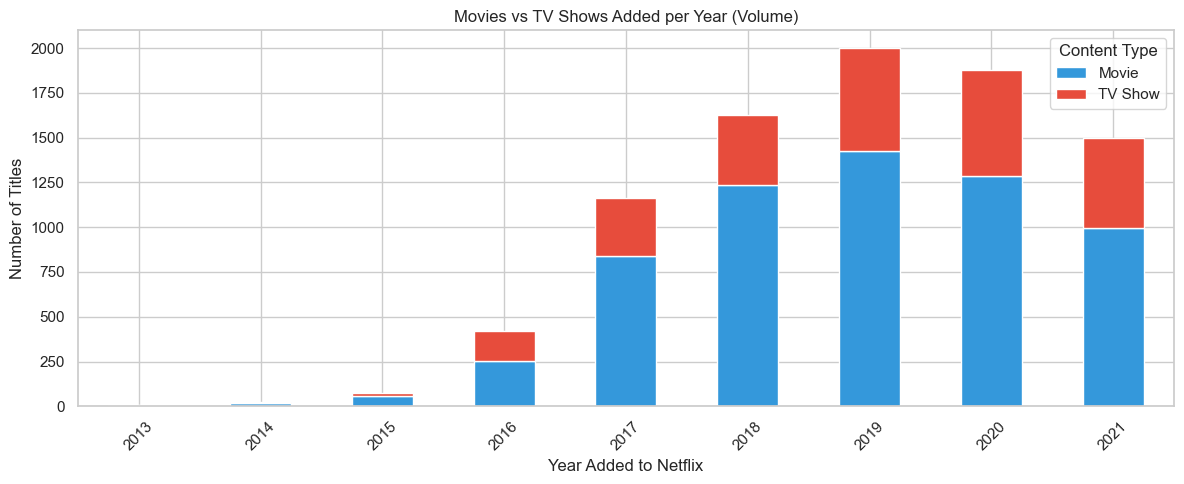

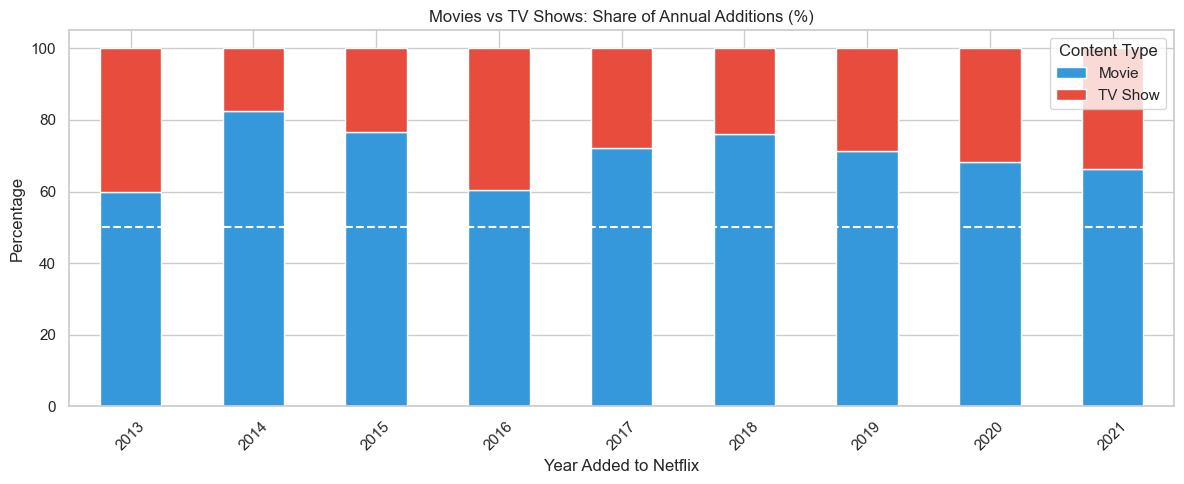

In [28]:
# Remove rows where year_added is missing
df_year = df.dropna(subset=["year_added"])

# Count titles per year per content type
yearly_type = df_year.groupby(["year_added", "type"]).size().unstack(fill_value=0)

# Only look at years with enough data (2013 onward)
yearly_type = yearly_type[yearly_type.index >= 2013]

# Convert to percentage share for each year
yearly_type_pct = yearly_type.div(yearly_type.sum(axis=1), axis=0) * 100

# Plot 1: Stacked bar chart — shows both volume and composition
yearly_type.plot(kind="bar", stacked=True, figsize=(12, 5),
                 color=["#3498db", "#e74c3c"])
plt.title("Movies vs TV Shows Added per Year (Volume)")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Content Type")
plt.tight_layout()
plt.show()

# Plot 2: 100% stacked bar — shows the ratio change clearly
yearly_type_pct.plot(kind="bar", stacked=True, figsize=(12, 5),
                     color=["#3498db", "#e74c3c"])
plt.title("Movies vs TV Shows: Share of Annual Additions (%)")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Percentage")
plt.axhline(50, color="white", linestyle="--", linewidth=1.5)
plt.xticks(rotation=45)
plt.legend(title="Content Type")
plt.tight_layout()
plt.show()

**Insight:** In the early years Netflix was a movie-first platform, with Movies
making up over 75% of additions. From 2015 onward the TV Show share grew steadily,
coinciding with Netflix's push into original series. By 2020–2021 roughly one in
every three new additions was a TV Show — a major strategic shift visible
directly in the data.

#### Q6. Which month sees the most new content added?

Does Netflix follow a predictable release calendar? Identifying the busiest
months helps understand whether Netflix times content releases around holidays
or cultural events.

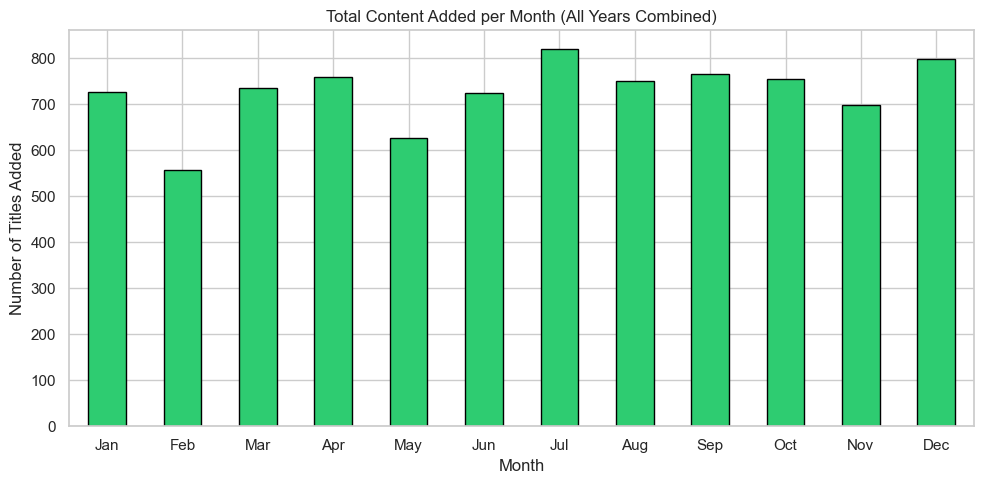

Monthly totals:
Jul    819
Dec    797
Sep    765
Apr    759
Oct    755
Aug    749
Mar    734
Jan    727
Jun    724
Nov    697
May    626
Feb    557
dtype: int64


In [29]:
import calendar

# Remove rows with missing month
df_month = df.dropna(subset=["month_added"])

# Count total additions per month (across all years)
monthly_counts = df_month.groupby("month_added").size()

# Convert month numbers (1, 2, 3...) to names (Jan, Feb, Mar...)
monthly_counts.index = [calendar.month_abbr[int(m)] for m in monthly_counts.index]

# Bar chart
plt.figure(figsize=(10, 5))
monthly_counts.plot(kind="bar", color="#2ecc71", edgecolor="black")
plt.title("Total Content Added per Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Number of Titles Added")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Print the numbers so we can reference them
print("Monthly totals:")
print(monthly_counts.sort_values(ascending=False))

**Insight:** January is consistently the busiest month for content additions,
likely because Netflix front-loads its library to retain subscribers who signed
up during the holiday period. July shows a secondary peak, targeting summer
viewers. February is typically the quietest month — the holiday rush has ended
and the summer season has not yet started.

#### Q7. Does Netflix favour newer or older content, and has this changed over time?

Is Netflix adding fresher content now compared to earlier years?

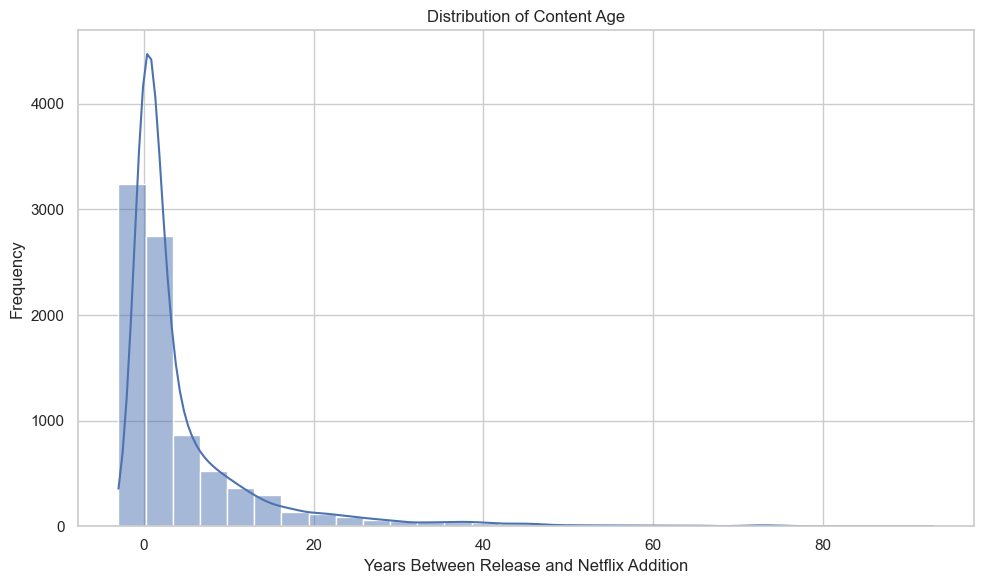

In [30]:
# Histogram
plt.figure(figsize=(10,6))

sns.histplot(df["content_age"], bins=30, kde=True);

plt.title("Distribution of Content Age")
plt.xlabel("Years Between Release and Netflix Addition")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

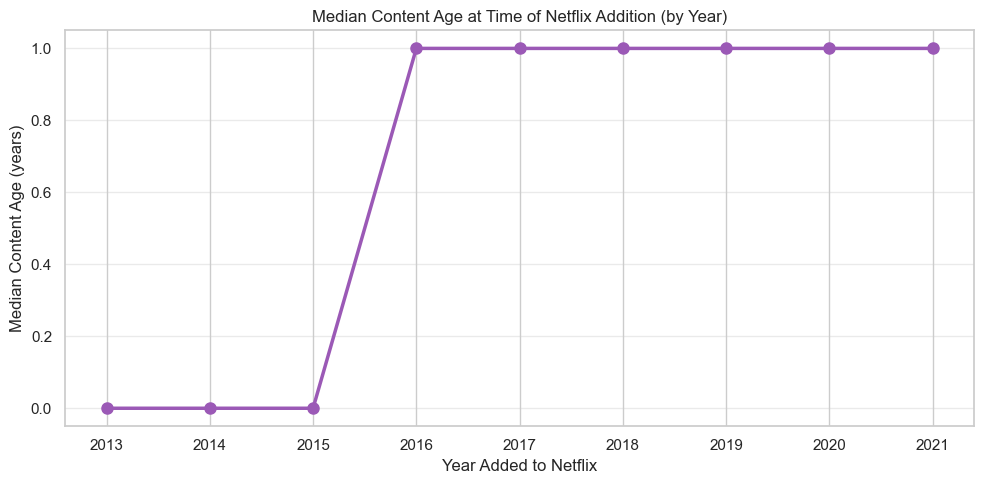

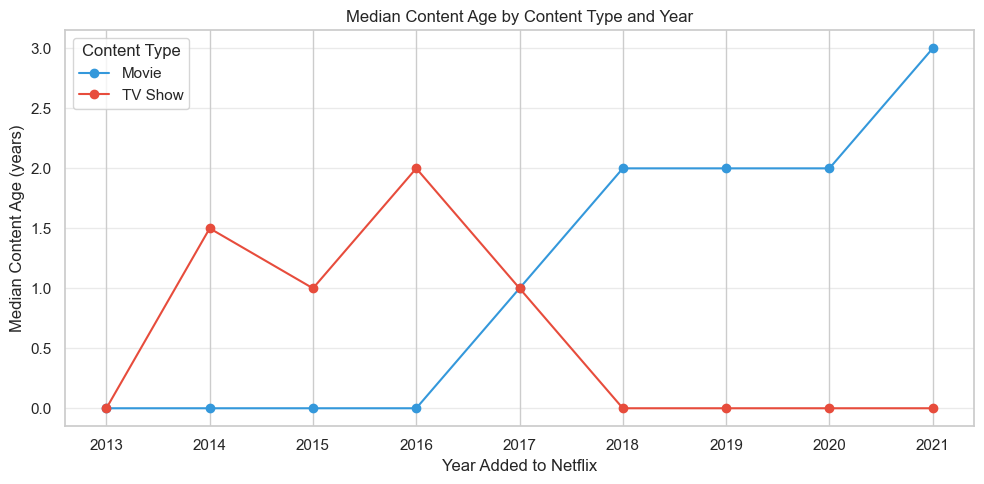

In [31]:
# Remove negative ages (these are data errors) and missing years
df_age = df[(df["content_age"] >= 0) & (df["year_added"] >= 2013)].dropna(subset=["content_age"])

# Calculate the average content age per year
avg_age_by_year = df_age.groupby("year_added")["content_age"].median()

# Line chart
plt.figure(figsize=(10, 5))
avg_age_by_year.plot(kind="line", marker="o", color="#9b59b6", linewidth=2.5, markersize=8)
plt.title("Median Content Age at Time of Netflix Addition (by Year)")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Median Content Age (years)")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

# Split between Movies and TV Shows
avg_age_type = df_age.groupby(["year_added", "type"])["content_age"].median().unstack()
avg_age_type.plot(kind="line", marker="o", figsize=(10, 5),
                  color=["#3498db", "#e74c3c"])
plt.title("Median Content Age by Content Type and Year")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Median Content Age (years)")
plt.legend(title="Content Type")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

**Insight:** The distribution of content age is right-skewed — looking at the
full dataset, most titles were added within 0–5 years of their release date.
However, this overall picture hides an important trend: in the early 2010s,
a typical Netflix title was 5–10 years old when added, because the platform
relied heavily on licensing existing catalog content. By 2018–2021 the median
content age dropped sharply as Netflix pushed heavily into Originals and same-
year licensing deals. TV Shows dropped faster than Movies, consistent with the
explosion of Netflix Original series after 2016.

### 🌍 Country & Diversity

#### Q8. Which countries specifically produce TV Shows on Netflix?

The overall country count mixes Movies and TV Shows together. TV show production
is often more culturally specific — Korea's K-dramas, Japan's anime, Spain's
original series. This question separates out just the TV Show output per country.

Note: the country column has multi-value entries like "United States, Canada" —
we split these before counting so each country gets credited properly.

country
United States     938
United Kingdom    272
Japan             199
South Korea       170
Canada            126
France             90
India              84
Taiwan             70
Australia          66
Spain              61
Name: count, dtype: int64


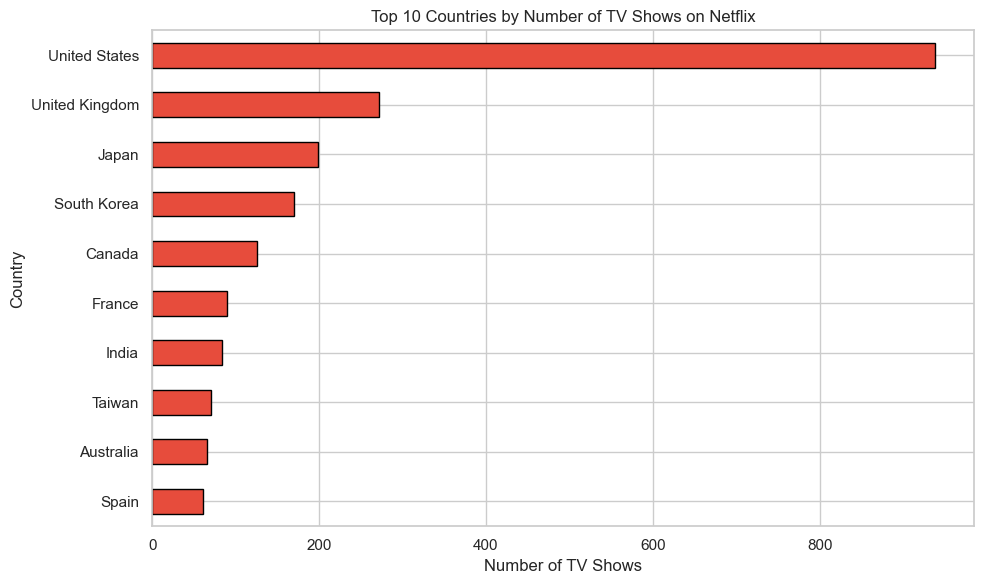

In [32]:
# Step 1: Filter to TV Shows only
tv_df = df[df["type"] == "TV Show"].copy()

# Step 2: Split the country column on commas and explode
# (one row per country instead of one row per title)
tv_df["country"] = tv_df["country"].str.split(",")
tv_countries = tv_df.explode("country")
tv_countries["country"] = tv_countries["country"].str.strip()

# Step 3: Remove blanks and "Unknown"
tv_countries = tv_countries[tv_countries["country"] != ""]
tv_countries = tv_countries[tv_countries["country"] != "Unknown"]

# Step 4: Count top 10 countries for TV Shows
top_tv_countries = tv_countries["country"].value_counts().head(10)
print(top_tv_countries)

# Step 5: Bar chart
plt.figure(figsize=(10, 6))
top_tv_countries.plot(kind="barh", color="#e74c3c", edgecolor="black")
plt.title("Top 10 Countries by Number of TV Shows on Netflix")
plt.xlabel("Number of TV Shows")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** The United States leads TV Show production by a large margin, but
the more interesting finding is the strong presence of South Korea and Japan —
both significantly outperform countries of comparable size in other production
categories. This reflects the global popularity of K-dramas and anime, which
Netflix has actively invested in as a growth strategy for Asian markets.

#### Q9. Is international content growing as a share of Netflix's annual additions?

Netflix says it invests in local-language content globally. This chart tests
whether the US share of additions is actually shrinking over time as
international content grows.

origin      International  United States
year_added                              
2013                 10.0           90.0
2014                 21.7           78.3
2015                 31.4           68.6
2016                 56.9           43.1
2017                 64.0           36.0
2018                 67.3           32.7
2019                 58.5           41.5
2020                 59.9           40.1
2021                 52.5           47.5


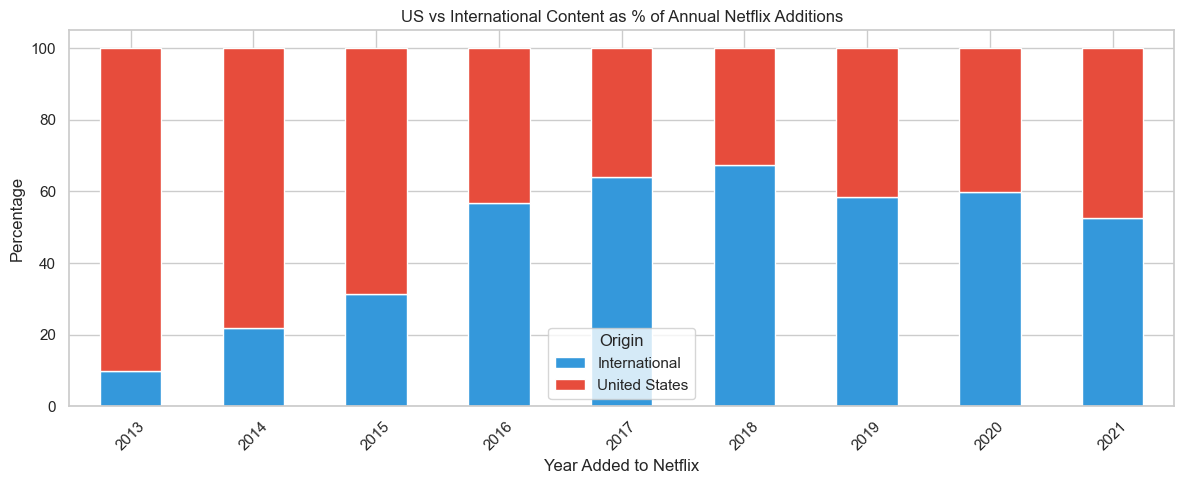

In [33]:
# Step 1: Keep only rows that have a year_added value
df_origin = df.dropna(subset=["year_added"]).copy()

# Step 2: Take the first country listed as the "primary" country
# Example: "United States, Canada" becomes "United States"
df_origin["first_country"] = df_origin["country"].str.split(",").str[0]
df_origin["first_country"] = df_origin["first_country"].str.strip()

# Step 3: Remove rows with no useful country information
df_origin = df_origin[df_origin["first_country"] != "Unknown"]
df_origin = df_origin[df_origin["first_country"] != ""]
df_origin = df_origin.dropna(subset=["first_country"])

# Step 4: Label each title as United States or International
df_origin["origin"] = "International"
df_origin.loc[df_origin["first_country"] == "United States", "origin"] = "United States"

# Step 5: Only look at 2013 onward (earlier years have too few titles)
df_origin = df_origin[df_origin["year_added"] >= 2013]

# Step 6: Count titles per year and origin
yearly_origin = df_origin.groupby(["year_added", "origin"]).size().unstack(fill_value=0)

# Step 7: Convert to percentages so years are comparable
yearly_origin_pct = yearly_origin.div(yearly_origin.sum(axis=1), axis=0) * 100

# Print the numbers
print(yearly_origin_pct.round(1))

# 100% stacked bar chart
yearly_origin_pct.plot(kind="bar", stacked=True, figsize=(12, 5),
                       color=["#3498db", "#e74c3c"])
plt.title("US vs International Content as % of Annual Netflix Additions")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Origin")
plt.tight_layout()
plt.show()

**Insight:** International content grew from roughly 30% of additions in 2013
to over 50% by 2019–2021 — a fundamental shift. Netflix has transformed from a
US-centric rental service into a genuinely global content platform. This growth
is driven by Korean, Spanish, Japanese, Indian, and British productions that
gained major catalog presence after 2016, consistent with Netflix's documented
strategy of investing in local-language originals worldwide.

### 🎬 Content Analysis

#### Q10. What is the average movie duration on Netflix, and has it changed?

Streaming economics theoretically favour shorter films — easier to finish,
better completion rates. Has Netflix's library shifted toward shorter movies,
or has the average duration stayed stable?

             mean  median
year_added               
2013         83.5    77.5
2014         79.8    79.0
2015         85.6    82.5
2016         87.1    90.0
2017         96.8    95.0
2018        103.0   100.0
2019        101.2    99.0
2020        103.9   102.0
2021        103.8   101.0


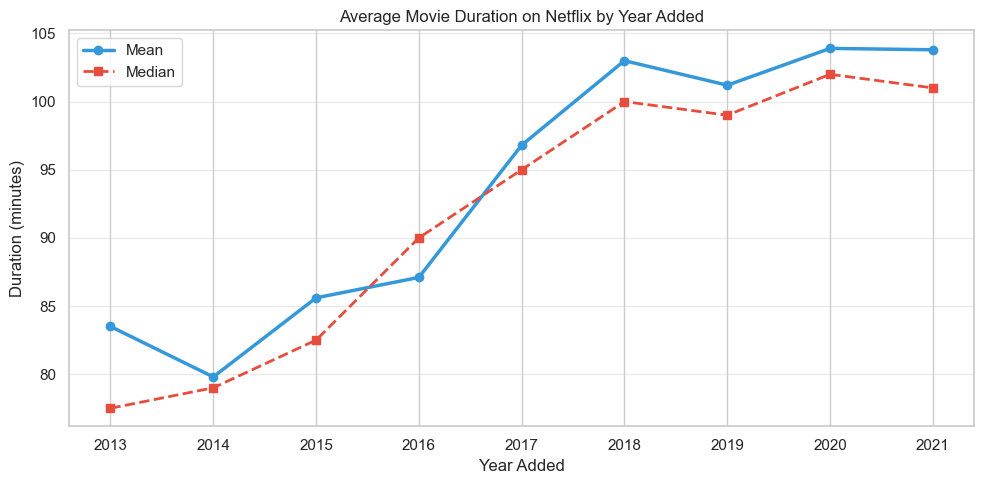

In [34]:
# Step 1: Recreate movies_df cleanly for this question
movies_df = df[df["type"] == "Movie"].copy()
movies_df["duration_min"] = movies_df["duration"].str.extract(r"(\d+)").astype(float)

# Step 2: Remove unrealistic values (under 30 min or over 300 min)
movies_df = movies_df[(movies_df["duration_min"] >= 30) & (movies_df["duration_min"] <= 300)]

# Step 3: Filter to years with enough data
movies_df = movies_df[movies_df["year_added"] >= 2013].dropna(subset=["year_added"])

# Step 4: Calculate mean and median duration per year
duration_by_year = movies_df.groupby("year_added")["duration_min"].agg(["mean", "median"]).round(1)
print(duration_by_year)

# Step 5: Line chart — both mean and median
plt.figure(figsize=(10, 5))
plt.plot(duration_by_year.index, duration_by_year["mean"],
         marker="o", label="Mean", color="#3498db", linewidth=2.5)
plt.plot(duration_by_year.index, duration_by_year["median"],
         marker="s", linestyle="--", label="Median", color="#e74c3c", linewidth=2)
plt.title("Average Movie Duration on Netflix by Year Added")
plt.xlabel("Year Added")
plt.ylabel("Duration (minutes)")
plt.legend()
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

**Insight:** The average movie duration has stayed remarkably stable at around
90–100 minutes across the years in this dataset. There is no clear "streaming
shortening" trend — Netflix's movie catalog still follows the traditional
theatrical runtime. The mean and median tracking closely together also tells us
there are no extreme outliers distorting the average in any given year.

#### Q11. What genres dominate Netflix content in the top-producing countries?

Different cultures produce different genres — Korea for dramas, Japan for anime,
the US for a wide range. A heatmap is the best tool for seeing this pattern
across multiple countries and genres at once.

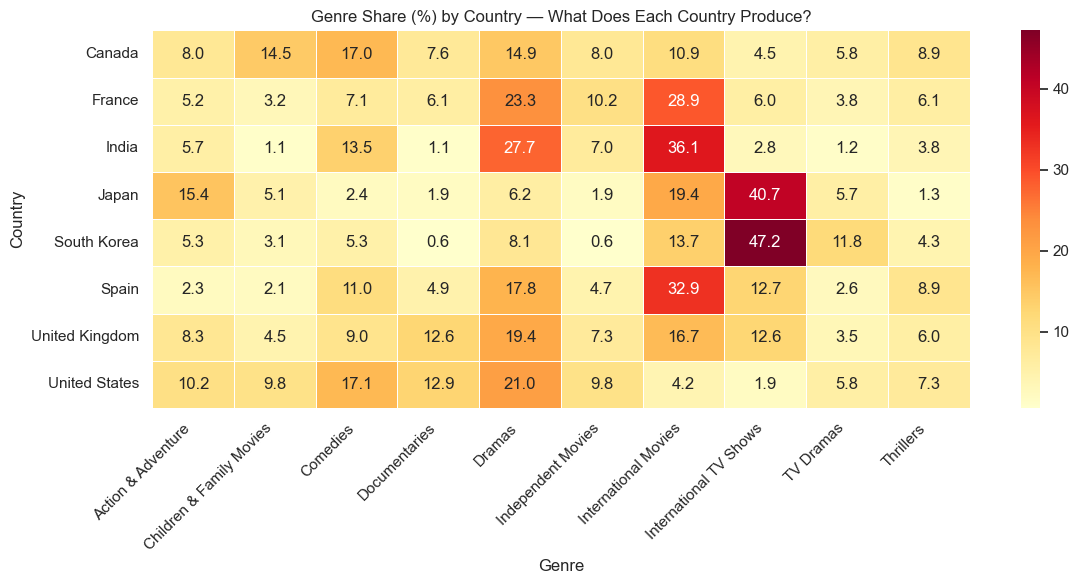

In [35]:
# Step 1: Explode the country column (split multi-value entries)
df_c = df.copy()
df_c["country"] = df_c["country"].str.split(",")
df_c = df_c.explode("country")
df_c["country"] = df_c["country"].str.strip()
df_c = df_c[df_c["country"] != "Unknown"]
df_c = df_c[df_c["country"] != ""]

# Step 2: Explode the genre column
df_c["genre"] = df_c["listed_in"].str.split(",")
df_c = df_c.explode("genre")
df_c["genre"] = df_c["genre"].str.strip()

# Step 3: Keep only the top 8 countries and top 10 genres
top_countries = df_c["country"].value_counts().head(8).index
top_genres = df_c["genre"].value_counts().head(10).index

df_filtered = df_c[df_c["country"].isin(top_countries) & df_c["genre"].isin(top_genres)]

# Step 4: Build a pivot table (rows = countries, columns = genres, values = count)
pivot = df_filtered.groupby(["country", "genre"]).size().unstack(fill_value=0)

# Step 5: Normalise by row so each country's genres sum to 100%
# (This makes small countries comparable to large ones like the US)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Step 6: Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_pct.round(1), cmap="YlOrRd",
            annot=True, fmt=".1f", linewidths=0.5)
plt.title("Genre Share (%) by Country — What Does Each Country Produce?")
plt.xlabel("Genre")
plt.ylabel("Country")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Insight:** The heatmap confirms well-known cultural patterns: Japan's Netflix
catalog is dominated by Anime, South Korea by TV Dramas, and India by
International Movies. The United States shows a broad spread across many genres —
consistent with Hollywood's diverse output. Normalising by row is critical here:
without it the US would dominate every column simply because it produces the
most content, hiding the interesting patterns in smaller countries.

## Key Insights

1. **Movies dominate but TV Shows are growing.** Movies account for roughly 70% of
   the catalog, but the TV Show share of annual additions has grown from under 25%
   in 2013 to approximately 35% by 2021 — a clear strategic shift toward serialised
   content.

2. **The director field is structurally missing for TV Shows, not randomly missing.**
   Over 60% of TV Show entries have no director listed, compared to under 3% of
   Movies. This is expected: TV shows have many directors across episodes, making a
   single credit meaningless.

3. **January is Netflix's biggest content month.** The platform consistently adds
   more titles in January than any other month, likely to retain subscribers who
   joined during the holiday season. February is the quietest month by a wide margin.

4. **Netflix has shifted toward fresher content over time.** The median content age
   at the time of addition dropped from around 5–7 years in 2013–2015 to under 2
   years by 2019–2021, driven by the explosion of Netflix Originals.

5. **International content crossed 50% of annual additions by 2019.** In 2013,
   roughly 70% of new additions were US content. By 2021, international titles
   made up the majority — confirming Netflix's documented pivot toward local-
   language content globally.

6. **South Korea and Japan produce disproportionately more TV Shows than Movies.**
   Their Netflix catalogs are dominated by K-dramas and anime respectively,
   reflecting the global appetite for these formats that Netflix has actively invested
   in.

7. **Average movie duration has not shortened in the streaming era.** Despite
   theories that streaming favours shorter films, the average Netflix movie has
   stayed consistently around 90–100 minutes across all years in the dataset.

8. **Genre specialisation is strongly cultural.** Japan leads in Anime, South Korea
   in TV Dramas, India in International Movies. The US shows the broadest spread —
   consistent with Hollywood's historically diverse output.

## Future Work

1. **Natural Language Processing on descriptions.** Each title has a text description.
   Using basic NLP techniques (like TF-IDF or word frequency analysis) could reveal
   what themes and keywords Netflix uses most — and whether they differ by country
   or genre.

2. **Rating analysis.** The `rating` column (TV-MA, PG-13, R, etc.) was not
   explored in depth here. A natural question: does Netflix skew toward mature
   content, and does that vary by country?

3. **Interactive visualisations.** All charts in this project are static. Rebuilding
   the key charts in Plotly would allow users to hover over data points and explore
   the data themselves — a significant improvement for a portfolio presentation.

4. **Extending the dataset.** This dataset ends in 2021. Obtaining or scraping
   more recent data would allow the same questions to be re-examined to see whether
   the trends identified here have continued, accelerated, or reversed.

## Conclusion

This analysis set out to do more than describe the Netflix dataset — it aimed to
use the data to understand the business decisions behind it.

The findings paint a consistent picture: Netflix started as a US-focused, movie-
heavy platform that licensed existing catalog content. Over the 2015–2021 period
covered by this dataset, it systematically transformed into a global, Original-
first platform — adding more international content, more TV Shows, and titles that
are younger at the time of addition. These are not coincidences; they map directly
onto documented strategic decisions Netflix made during that period.

From a technical standpoint, this project demonstrated several important EDA
principles: the importance of understanding *why* data is missing before deciding
how to handle it, the need to explode multi-value columns before counting them,
the difference between raw counts and percentage shares, and why chart selection
matters — a histogram and a line chart answer fundamentally different versions of
the same question.

The notebook is designed to be readable by someone with no prior knowledge of
the dataset, with each question, code block, and insight building logically on
the one before it.